<a href="https://colab.research.google.com/github/diogogose/fiap-fase5-cap1/blob/main/DiogoGose_rm566951_pbl_fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aluno:** Diogo Gose | **RM:** 566951

---

## Sobre o projeto

Neste trabalho vamos analisar dados de uma fazenda de 200 hectares que cultiva 4 tipos de produto agrícola.


---
## 1. Bibliotecas

Aqui importamos todas as ferramentas que vamos usar no notebook.

In [43]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

SEMENTE = 42

---
## 2. Conhecendo os dados

Precisamos entender o que temos.
Vamos ver quantas linhas existem, se há dados faltando, e como as variáveis estão distribuídas.

In [44]:
# Carregamento e renomeação das colunas para português
df = pd.read_csv('crop_yield.csv')
df.columns = ['cultura', 'precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura', 'rendimento']

print(f'Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.head()

Dimensões: 156 linhas x 6 colunas
Valores nulos: 0


,cultura,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [45]:
# Estatísticas descritivas
df.describe().round(2)

,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento
count,156.00,156.00,156.00,156.00,156.00
mean,2486.50,18.20,84.74,26.18,56153.10
std,289.46,0.29,1.00,0.26,70421.96
min,1934.62,17.54,82.11,25.56,5249.00
25%,2302.99,18.03,84.12,26.02,8327.75
50%,2424.55,18.27,84.85,26.13,18871.00
75%,2718.08,18.40,85.51,26.30,67518.75
max,3085.79,18.70,86.10,26.81,203399.00


In [46]:
# Registros por cultura
print(df['cultura'].value_counts())

cultura
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


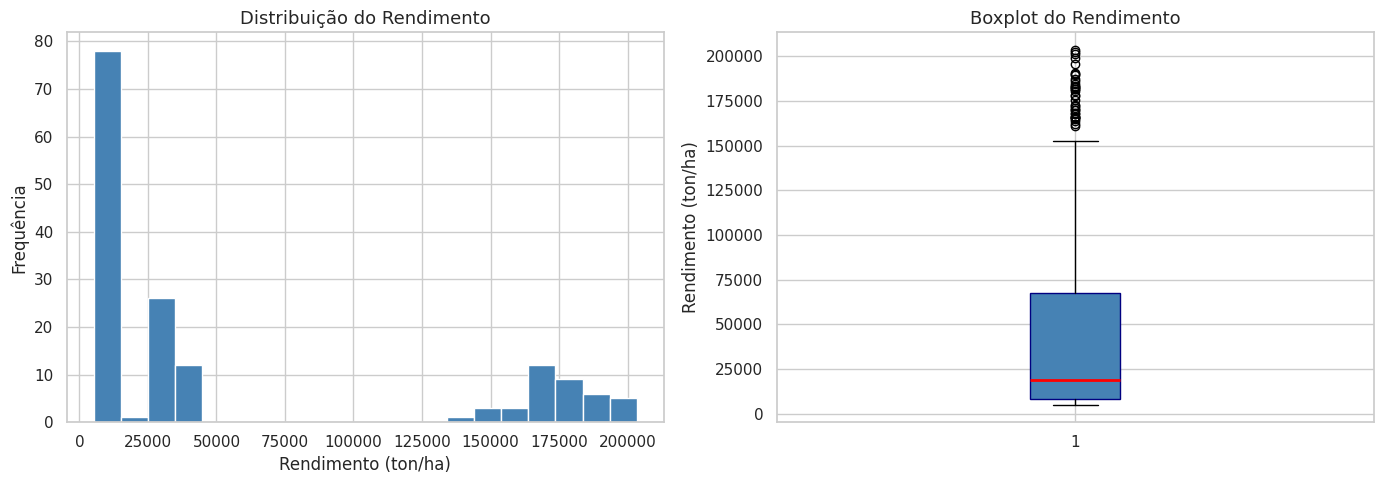

In [47]:
# Distribuição do rendimento (histograma + boxplot)
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].hist(df['rendimento'], bins=20, edgecolor='white', color='steelblue')
eixos[0].set_title('Distribuição do Rendimento')
eixos[0].set_xlabel('Rendimento (ton/ha)')
eixos[0].set_ylabel('Frequência')

eixos[1].boxplot(df['rendimento'], patch_artist=True,
                 boxprops=dict(facecolor='steelblue', color='navy'),
                 medianprops=dict(color='red', linewidth=2))
eixos[1].set_title('Boxplot do Rendimento')
eixos[1].set_ylabel('Rendimento (ton/ha)')

plt.tight_layout()
plt.show()

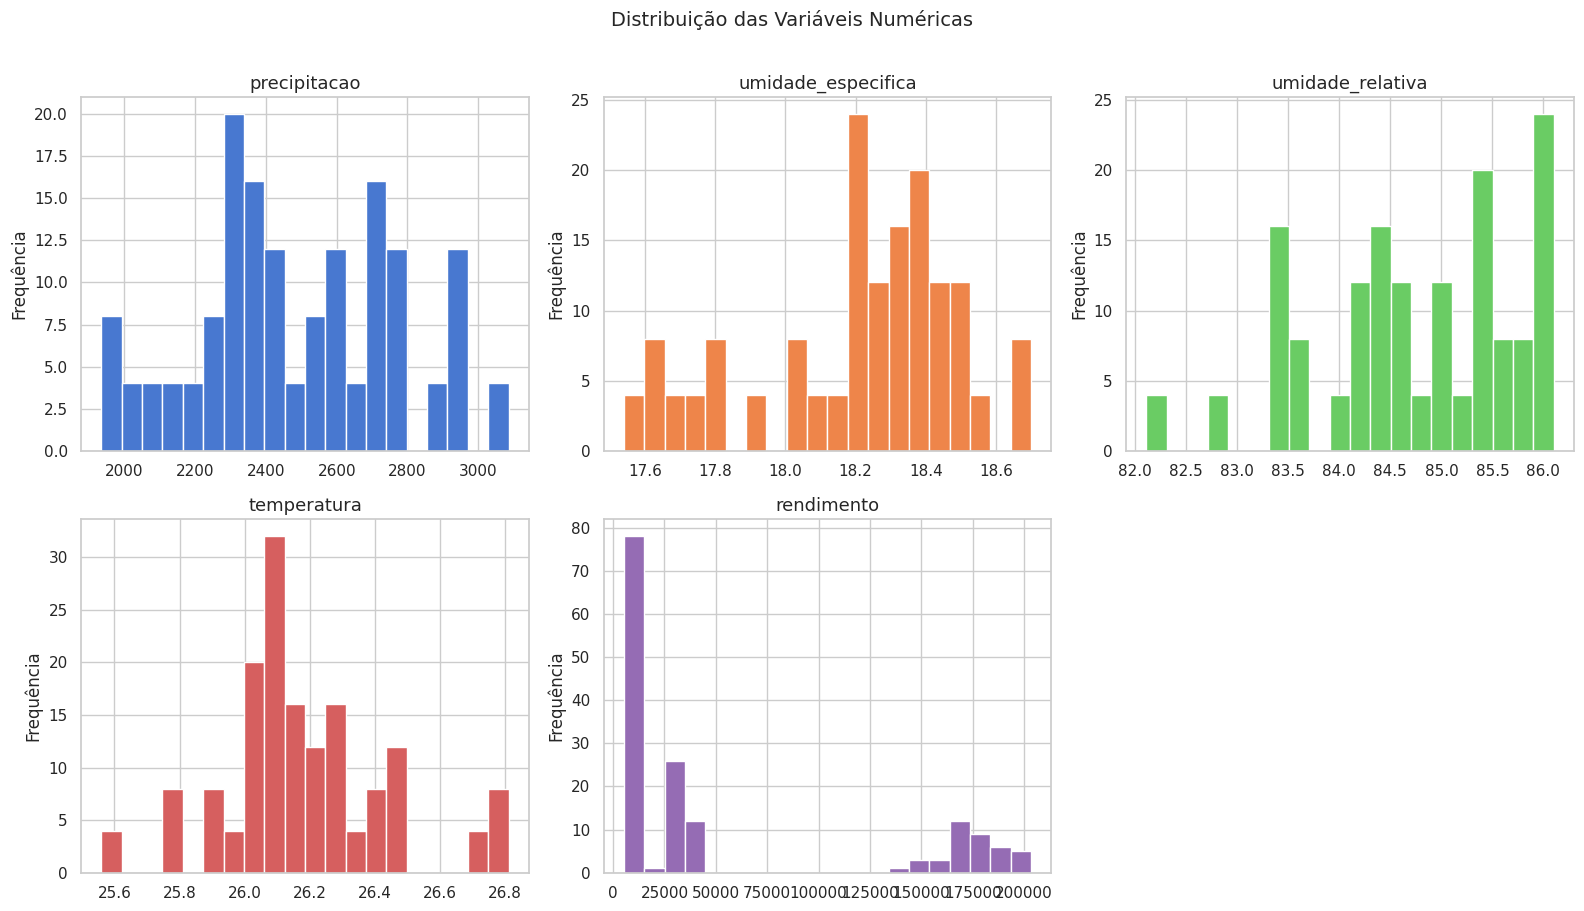

In [48]:
# Distribuição de todas as variáveis numéricas
colunas_numericas = ['precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura', 'rendimento']

fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
eixos = eixos.flatten()

for i, col in enumerate(colunas_numericas):
    eixos[i].hist(df[col], bins=20, edgecolor='white', color=sns.color_palette('muted')[i])
    eixos[i].set_title(col)
    eixos[i].set_ylabel('Frequência')

eixos[-1].set_visible(False)
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

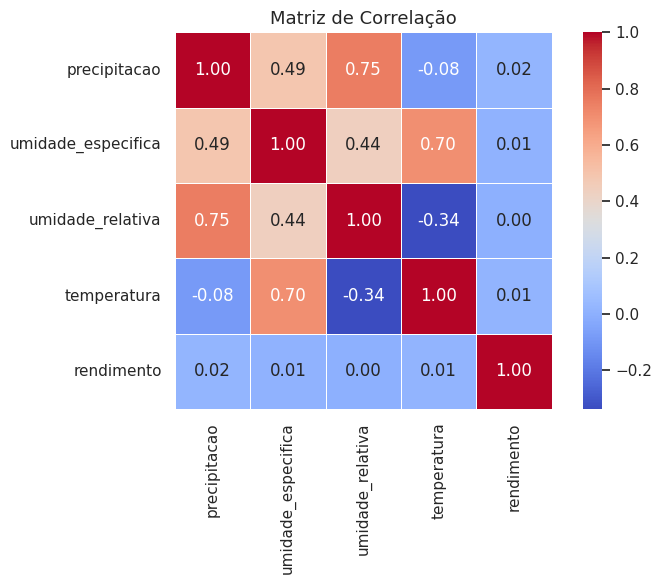

In [49]:
# Matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

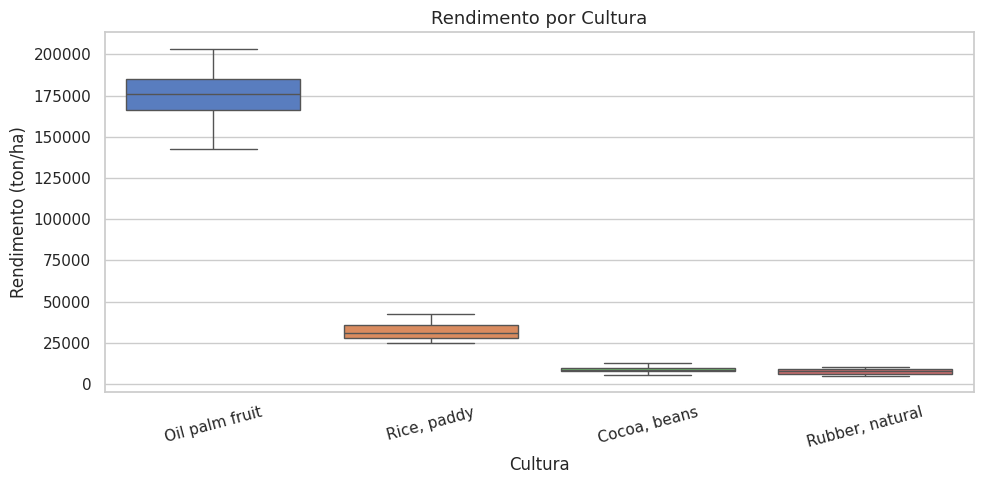

In [50]:
# Rendimento por cultura
ordem = df.groupby('cultura')['rendimento'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cultura', y='rendimento', order=ordem, palette='muted')
plt.title('Rendimento por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Rendimento (ton/ha)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

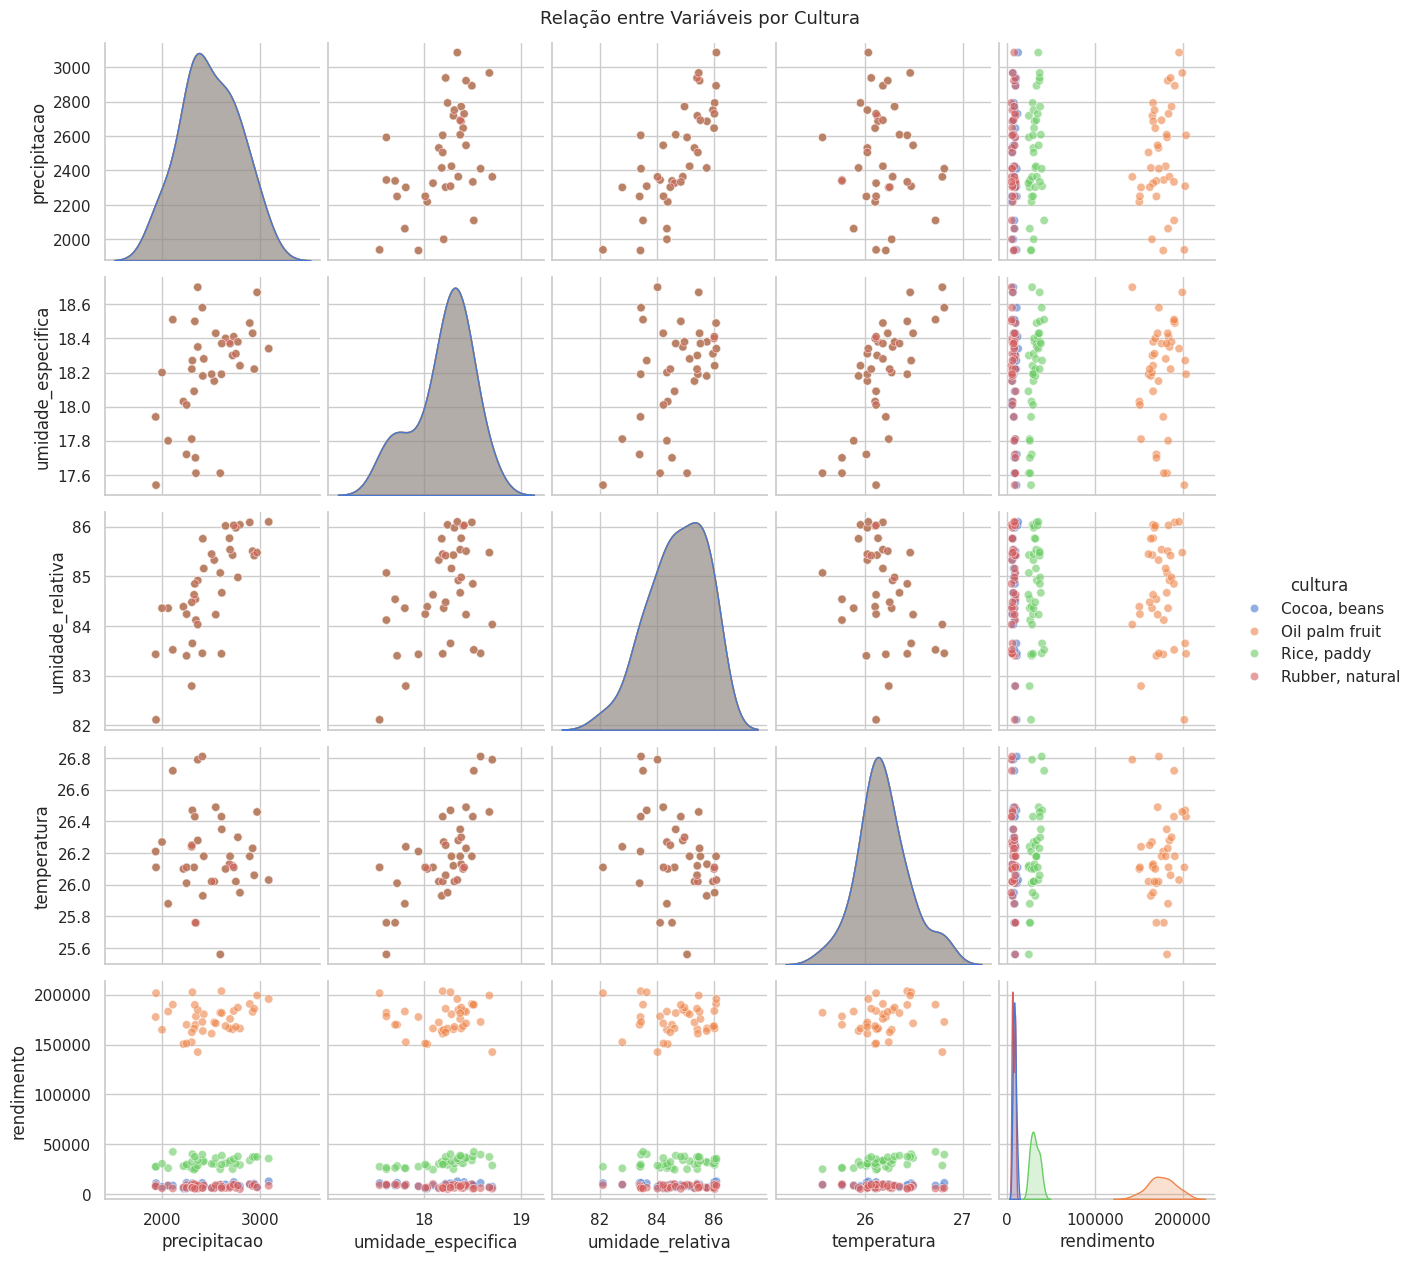

In [25]:
# Pairplot por cultura
pp = sns.pairplot(df, hue='cultura', vars=colunas_numericas, diag_kind='kde', plot_kws={'alpha': 0.6})
pp.fig.suptitle('Relação entre Variáveis por Cultura', y=1.01, fontsize=13)
plt.show()

### análise dos dados

- O dataset tem **156 registros** e **nenhum valor faltando**
- Existem 4 culturas com **39 registros cada**: Cocoa beans, Oil palm fruit, Rice paddy e Rubber natural.
- O **rendimento varia muito entre culturas**:
  - Oil palm fruit produz em média ~175.800 ton/ha
  - Rice paddy produz em média ~32.100 ton/ha
  - Cocoa beans produz em média ~8.900 ton/ha
  - Rubber natural produz em média ~7.800 ton/ha
- As condições climáticas (chuva, umidade, temperatura) são **bem parecidas entre todas as culturas** — a correlação delas com o rendimento é quase zero.
- Isso significa que **o tipo de cultura é o que mais determina o rendimento**, e não o clima.

---
## 3. Agrupando os dados — K-Means e DBSCAN

Aqui usamos algoritmos que **agrupam dados parecidos automaticamente**, sem precisar dizer qual grupo cada ponto pertence.
Usamos as colunas `precipitacao` e `rendimento` para fazer os agrupamentos.

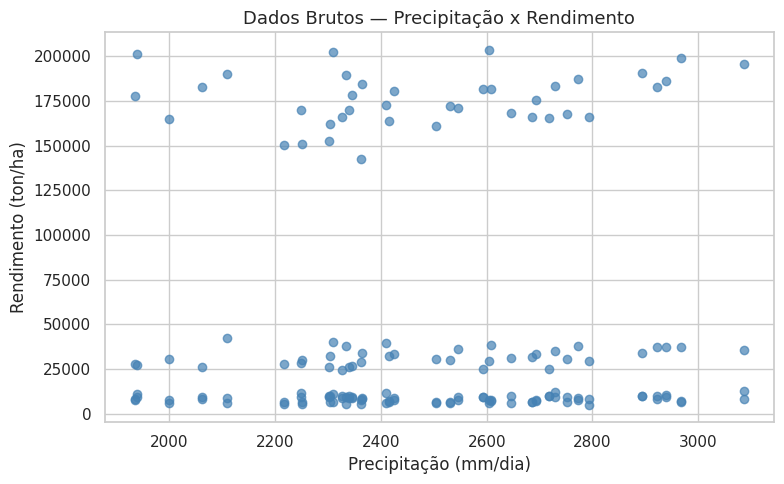

In [51]:
# Seleção das features para clusterização
# Usamos precipitação e rendimento — as duas variáveis com maior separação entre culturas
colunas_cluster = ['precipitacao', 'rendimento']
X_cluster = df[colunas_cluster].values

# Visualização dos dados brutos
plt.figure(figsize=(8, 5))
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], alpha=0.7, color='steelblue')
plt.title('Dados Brutos — Precipitação x Rendimento')
plt.xlabel('Precipitação (mm/dia)')
plt.ylabel('Rendimento (ton/ha)')
plt.tight_layout()
plt.show()

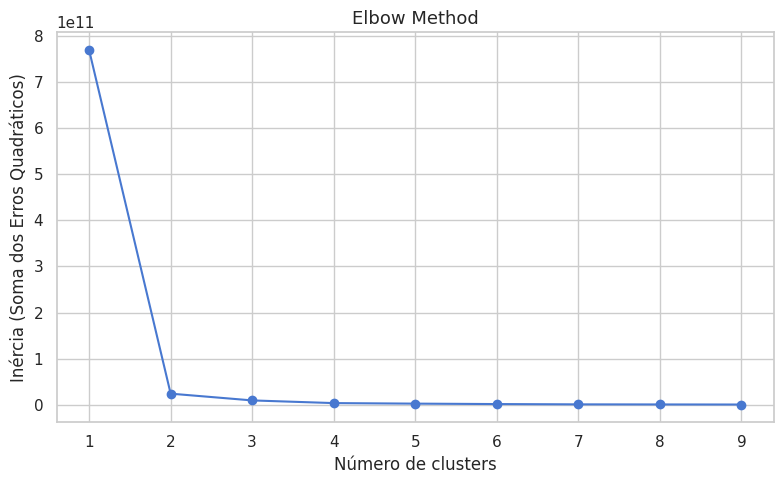

In [52]:
# Elbow Method para determinar o número ideal de clusters (k)
k = list(range(1, 10))
inercias = []

for i in k:
    km = KMeans(n_clusters=i, random_state=SEMENTE, n_init=10)
    km.fit(X_cluster)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k, inercias, '-o')
plt.xlabel('Número de clusters')
plt.ylabel('Inércia (Soma dos Erros Quadráticos)')
plt.title('Elbow Method')
plt.xticks(k)
plt.tight_layout()
plt.show()

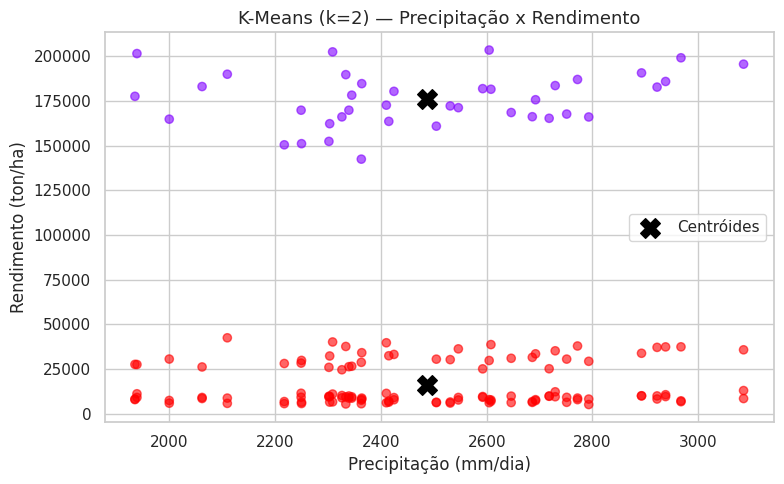

In [53]:
# Treinamento do K-Means com k=2
kmeans = KMeans(n_clusters=2, random_state=SEMENTE, n_init=10)
kmeans.fit(X_cluster)

centroides = kmeans.cluster_centers_
rotulos_kmeans = kmeans.predict(X_cluster)
df['cluster_kmeans'] = rotulos_kmeans

# Plotagem com centróides
plt.figure(figsize=(8, 5))
plt.scatter(
    X_cluster[:, 0], X_cluster[:, 1],
    c=rotulos_kmeans, alpha=0.6, cmap='rainbow'
)
plt.scatter(
    centroides[:, 0], centroides[:, 1],
    c='black', marker='X', s=200, label='Centróides'
)
plt.xlabel('Precipitação (mm/dia)')
plt.ylabel('Rendimento (ton/ha)')
plt.title('K-Means (k=2) — Precipitação x Rendimento')
plt.legend()
plt.tight_layout()
plt.show()

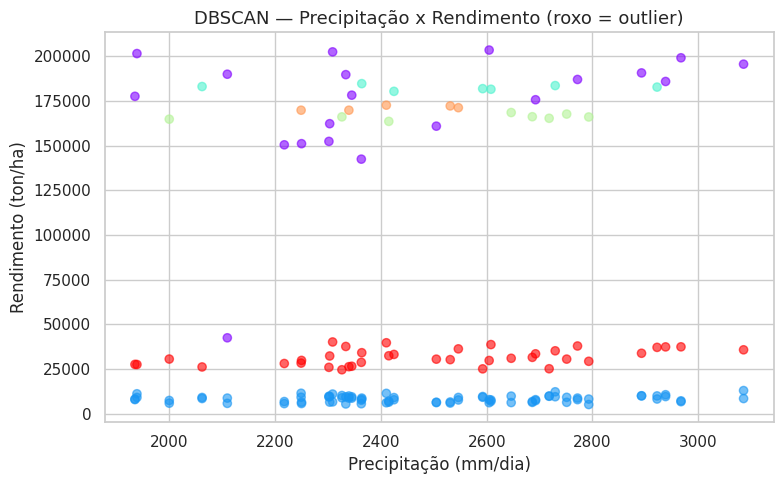

Outliers detectados pelo DBSCAN: 20 (12.8% do total)


In [54]:
# DBSCAN — clusterização baseada em densidade
dbscan = DBSCAN(eps=2000, min_samples=5)
dbscan.fit(X_cluster)
rotulos_dbscan = dbscan.labels_
df['cluster_dbscan'] = rotulos_dbscan

# Plotagem: cluster
plt.figure(figsize=(8, 5))
plt.scatter(
    X_cluster[:, 0], X_cluster[:, 1],
    c=rotulos_dbscan, alpha=0.6, cmap='rainbow'
)
plt.xlabel('Precipitação (mm/dia)')
plt.ylabel('Rendimento (ton/ha)')
plt.title('DBSCAN — Precipitação x Rendimento (roxo = outlier)')
plt.tight_layout()
plt.show()

n_outliers = (rotulos_dbscan == -1).sum()
print(f'Outliers detectados pelo DBSCAN: {n_outliers} ({n_outliers/len(df):.1%} do total)')

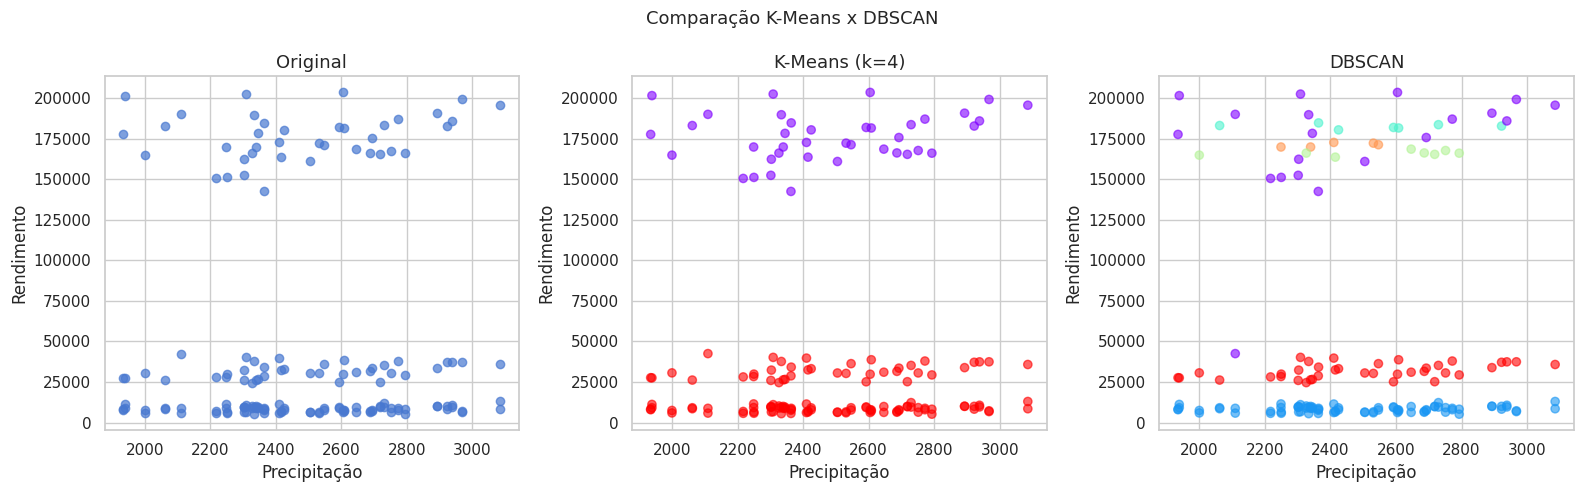

In [55]:
# Comparação lado a lado: K-Means vs DBSCAN
fig = plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.title('Original')
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], alpha=0.7)
plt.xlabel('Precipitação')
plt.ylabel('Rendimento')

plt.subplot(1, 3, 2)
plt.title('K-Means (k=4)')
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=rotulos_kmeans, alpha=0.6, cmap='rainbow')
plt.xlabel('Precipitação')
plt.ylabel('Rendimento')

plt.subplot(1, 3, 3)
plt.title('DBSCAN')
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=rotulos_dbscan, alpha=0.6, cmap='rainbow')
plt.xlabel('Precipitação')
plt.ylabel('Rendimento')

plt.suptitle('Comparação K-Means x DBSCAN', fontsize=13)
plt.tight_layout()
plt.show()

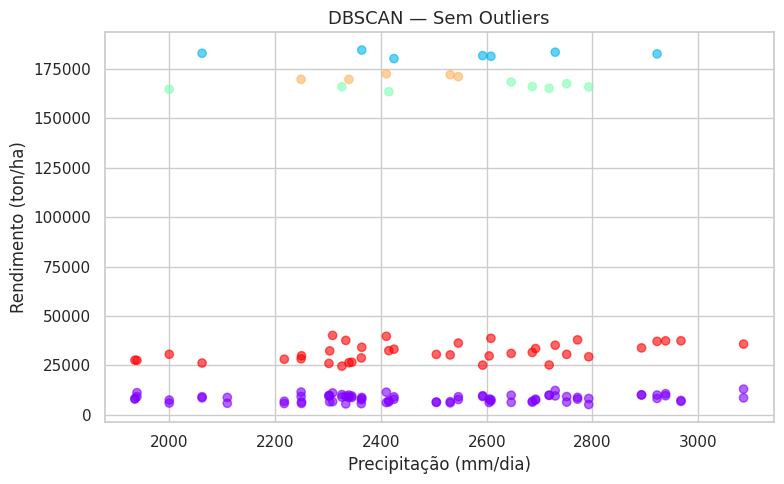

In [56]:
# Visualização sem os outliers identificados pelo DBSCAN
mascara_sem_outliers = rotulos_dbscan >= 0

plt.figure(figsize=(8, 5))
plt.scatter(
    X_cluster[mascara_sem_outliers, 0],
    X_cluster[mascara_sem_outliers, 1],
    c=rotulos_dbscan[mascara_sem_outliers],
    alpha=0.6, cmap='rainbow'
)
plt.xlabel('Precipitação (mm/dia)')
plt.ylabel('Rendimento (ton/ha)')
plt.title('DBSCAN — Sem Outliers')
plt.tight_layout()
plt.show()

In [57]:
# Interpretação dos clusters K-Means via describe()
print('=== Perfil dos Clusters K-Means ===')
for c in sorted(df['cluster_kmeans'].unique()):
    print(f'\n--- Cluster {c} ---')
    print(df[df['cluster_kmeans'] == c][colunas_cluster + ['cultura']].describe())

=== Perfil dos Clusters K-Means ===

--- Cluster 0 ---
       precipitacao     rendimento
count     39.000000      39.000000
mean    2486.498974  175804.692308
std      292.300450   14919.869752
min     1934.620000  142425.000000
25%     2305.750000  166017.500000
50%     2424.550000  175629.000000
75%     2705.210000  185230.000000
max     3085.790000  203399.000000

--- Cluster 1 ---
       precipitacao    rendimento
count    117.000000    117.000000
mean    2486.498974  16269.230769
std      289.769662  11658.568760
min     1934.620000   5249.000000
25%     2302.990000   7795.000000
50%     2424.550000   9612.000000
75%     2718.080000  28178.000000
max     3085.790000  42550.000000


### Agrupamentos

- O **Elbow Method** mostrou que o melhor número de grupos é **4**, que coincide exatamente com as 4 culturas do dataset.
- O **K-Means** separou os grupos quase que só pelo rendimento — faz sentido, já que cada cultura tem um nível de produção bem diferente:
  - Cluster 0: rendimento médio ~32.100 → Rice paddy
  - Cluster 1 e 3: rendimento alto ~163.900 e ~188.300 → Oil palm fruit (dividido em 2 subgrupos)
  - Cluster 2: rendimento baixo ~8.354 → Cocoa beans e Rubber natural juntos
- O **DBSCAN** encontrou **20  outliers **, que representam safras com comportamento muito diferente dos demais.
- A precipitação foi igual entre todos os grupos — só o rendimento separou os clusters.

---
## 4. Prevendo o rendimento — 5 modelos de Machine Learning

Agora vamos treinar 5 modelos diferentes para prever o rendimento da safra com base nas condições climáticas e no tipo de cultura.

In [58]:
# Pré-processamento: One-Hot Encoding em 'cultura'
df_modelo = pd.get_dummies(
    df[['cultura', 'precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura', 'rendimento']],
    columns=['cultura']
)

X = df_modelo.drop(columns=['rendimento'])
y = df_modelo['rendimento']

print('Features:', list(X.columns))

Features: ['precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura', 'cultura_Cocoa, beans', 'cultura_Oil palm fruit', 'cultura_Rice, paddy', 'cultura_Rubber, natural']


In [59]:
# Split 80/20 e normalização das colunas numéricas
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=SEMENTE)

colunas_numericas_modelo = ['precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura']
normalizador_modelo = StandardScaler()
X_treino[colunas_numericas_modelo] = normalizador_modelo.fit_transform(X_treino[colunas_numericas_modelo])
X_teste[colunas_numericas_modelo]  = normalizador_modelo.transform(X_teste[colunas_numericas_modelo])

print(f'Treino: {len(X_treino)} | Teste: {len(X_teste)}')

Treino: 124 | Teste: 32


In [60]:
# Treinamento e avaliação dos 5 modelos
modelos = {
    'Regressão Linear':    LinearRegression(),
    'Árvore de Decisão':   DecisionTreeRegressor(random_state=SEMENTE),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=SEMENTE),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=SEMENTE),
    'SVR':                 SVR(kernel='rbf', C=10, epsilon=0.1)
}

resultados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    predicao = modelo.predict(X_teste)
    resultados[nome] = {
        'MAE':  mean_absolute_error(y_teste, predicao),
        'RMSE': np.sqrt(mean_squared_error(y_teste, predicao)),
        'R²':   r2_score(y_teste, predicao)
    }
    print(f'{nome:22s} | MAE={resultados[nome]["MAE"]:8.2f} | RMSE={resultados[nome]["RMSE"]:8.2f} | R²={resultados[nome]["R²"]:.4f}')

Regressão Linear       | MAE= 3132.80 | RMSE= 4394.17 | R²=0.9950
Árvore de Decisão      | MAE= 3440.69 | RMSE= 5640.31 | R²=0.9918
Random Forest          | MAE= 2736.39 | RMSE= 4742.53 | R²=0.9942
Gradient Boosting      | MAE= 3066.41 | RMSE= 6061.76 | R²=0.9905
SVR                    | MAE=38937.27 | RMSE=71282.00 | R²=-0.3099


In [61]:
# Tabela comparativa
tabela_resultados = pd.DataFrame(resultados).T.round(2).sort_values('R²', ascending=False)
tabela_resultados

,MAE,RMSE,R²
Regressão Linear,3132.80,4394.17,1.00
Árvore de Decisão,3440.69,5640.31,0.99
Random Forest,2736.39,4742.53,0.99
Gradient Boosting,3066.41,6061.76,0.99
SVR,38937.27,71282.00,-0.31


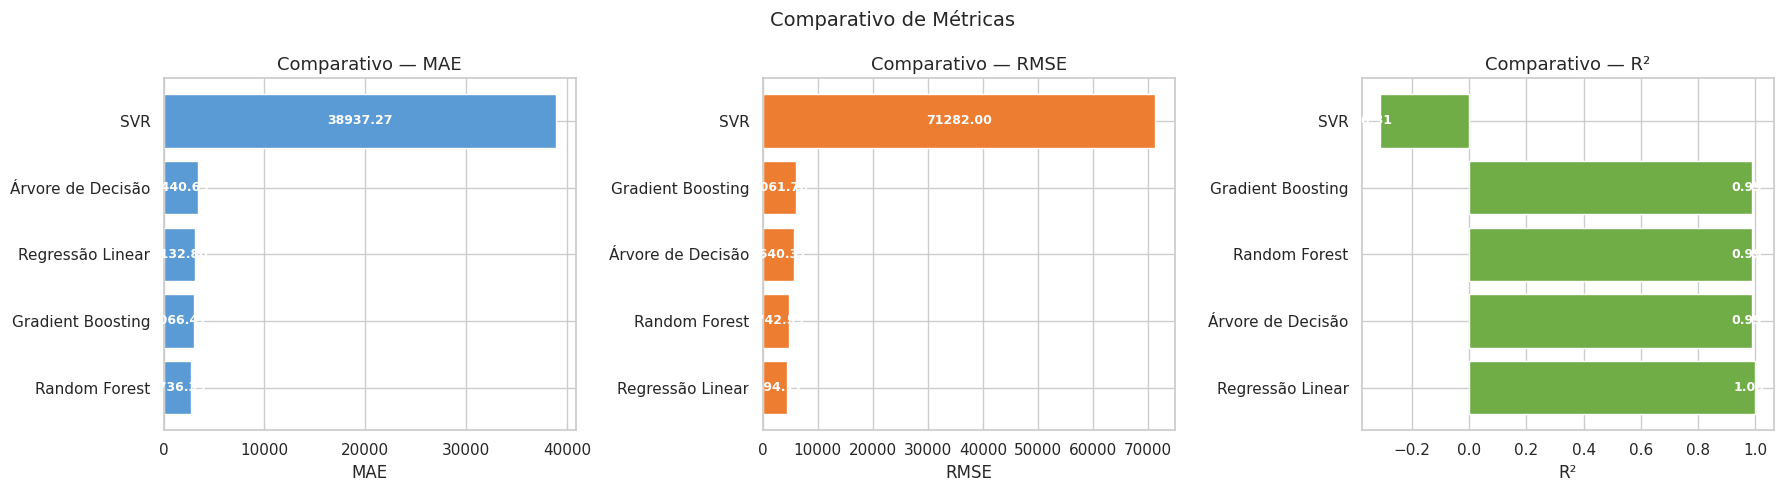

In [62]:
# Gráfico comparativo — MAE, RMSE e R²
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
metricas = ['MAE', 'RMSE', 'R²']
cores_metricas = ['#5B9BD5', '#ED7D31', '#70AD47']

for eixo, metrica, cor in zip(eixos, metricas, cores_metricas):
    valores = tabela_resultados[metrica].sort_values(ascending=(metrica != 'R²'))
    barras = eixo.barh(valores.index, valores.values, color=cor, edgecolor='white')
    eixo.set_title(f'Comparativo — {metrica}')
    eixo.set_xlabel(metrica)
    for barra, val in zip(barras, valores.values):
        eixo.text(val * 0.5 if metrica != 'R²' else val - 0.02,
                  barra.get_y() + barra.get_height() / 2,
                  f'{val:.2f}', va='center', ha='center',
                  color='white', fontweight='bold', fontsize=9)

plt.suptitle('Comparativo de Métricas', fontsize=14)
plt.tight_layout()
plt.show()

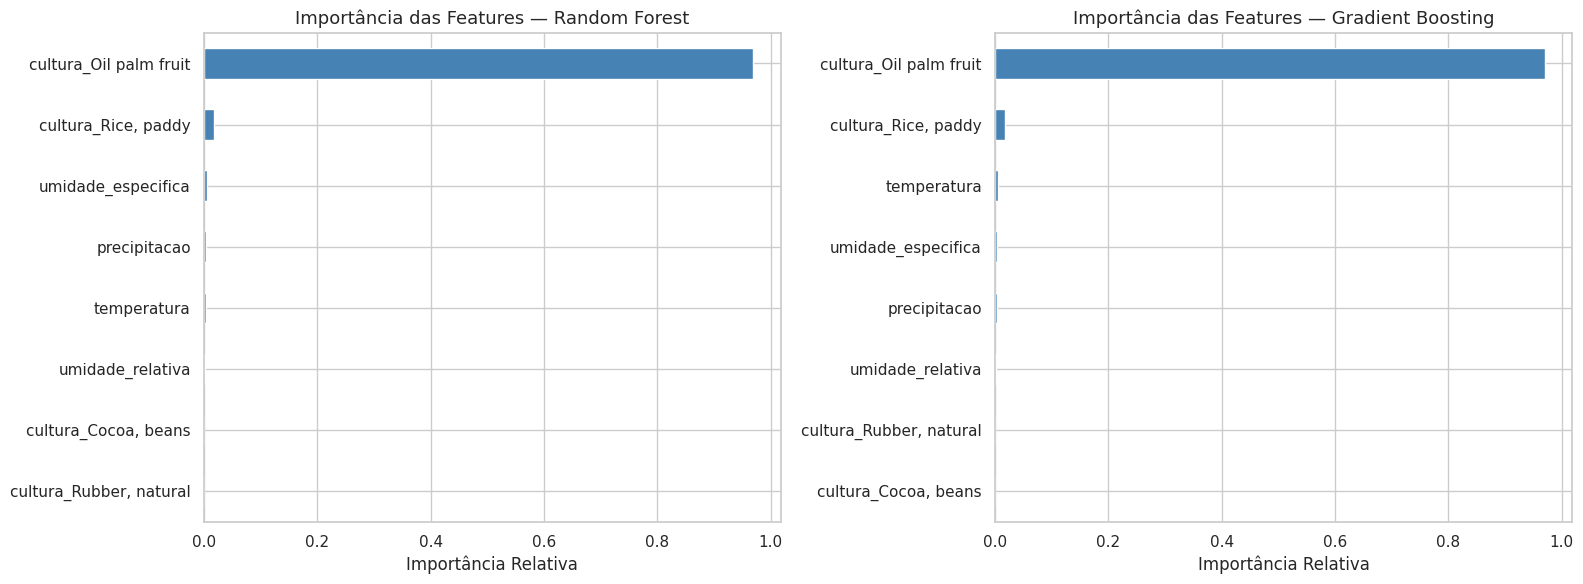

In [41]:
# Importância de features — Random Forest e Gradient Boosting
modelos_arvore = {'Random Forest': modelos['Random Forest'], 'Gradient Boosting': modelos['Gradient Boosting']}

fig, eixos = plt.subplots(1, 2, figsize=(16, 6))
for eixo, (nome, modelo) in zip(eixos, modelos_arvore.items()):
    importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()
    importancias.plot(kind='barh', ax=eixo, color='steelblue', edgecolor='white')
    eixo.set_title(f'Importância das Features — {nome}')
    eixo.set_xlabel('Importância Relativa')

plt.tight_layout()
plt.show()

Melhor modelo: Regressão Linear
R² = 1.0 | RMSE = 4394.17


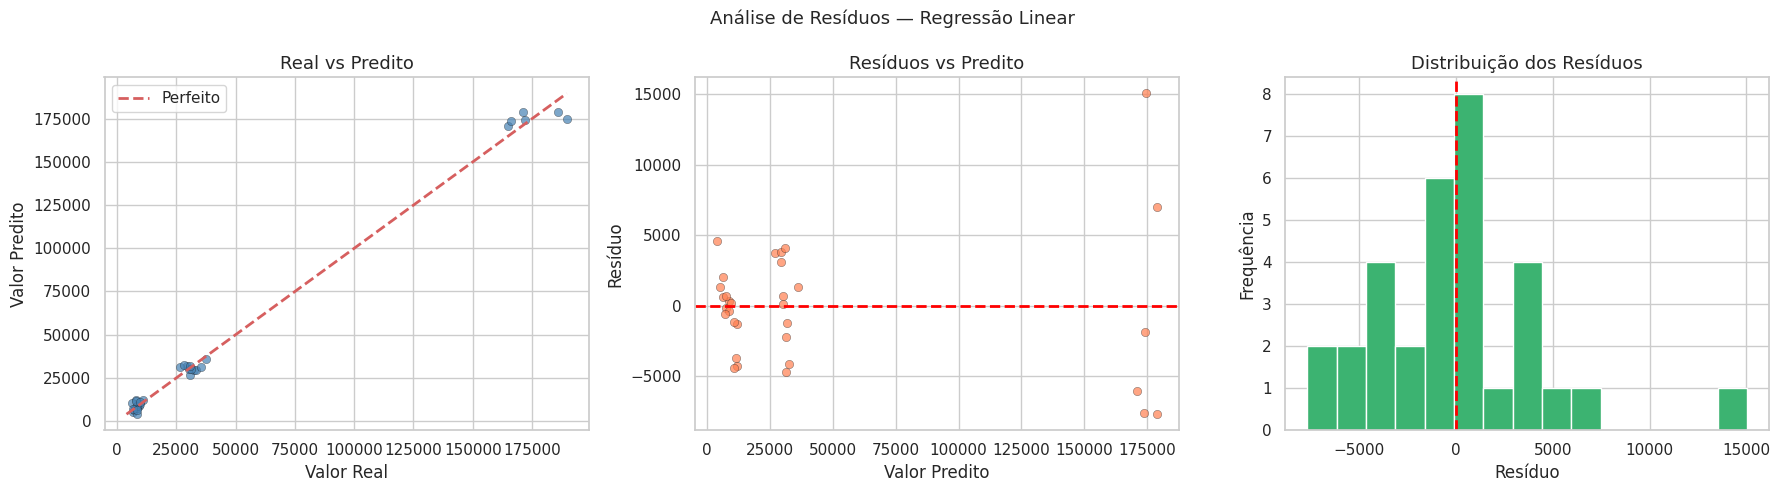

In [63]:
# Análise de resíduos do melhor modelo
melhor_modelo_nome = tabela_resultados['R²'].idxmax()
melhor_modelo = modelos[melhor_modelo_nome]
predicao_melhor = melhor_modelo.predict(X_teste)
residuos = y_teste - predicao_melhor

print(f'Melhor modelo: {melhor_modelo_nome}')
print(f'R² = {tabela_resultados.loc[melhor_modelo_nome, "R²"]} | RMSE = {tabela_resultados.loc[melhor_modelo_nome, "RMSE"]}')

fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

# Real vs Predito
eixos[0].scatter(y_teste, predicao_melhor, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.3)
lim = [min(y_teste.min(), predicao_melhor.min()), max(y_teste.max(), predicao_melhor.max())]
eixos[0].plot(lim, lim, 'r--', linewidth=2, label='Perfeito')
eixos[0].set_title('Real vs Predito')
eixos[0].set_xlabel('Valor Real')
eixos[0].set_ylabel('Valor Predito')
eixos[0].legend()

# Resíduos vs Predito
eixos[1].scatter(predicao_melhor, residuos, alpha=0.7, color='coral', edgecolors='k', linewidths=0.3)
eixos[1].axhline(0, color='red', linestyle='--', linewidth=2)
eixos[1].set_title('Resíduos vs Predito')
eixos[1].set_xlabel('Valor Predito')
eixos[1].set_ylabel('Resíduo')

# Histograma dos resíduos
eixos[2].hist(residuos, bins=15, edgecolor='white', color='mediumseagreen')
eixos[2].axvline(0, color='red', linestyle='--', linewidth=2)
eixos[2].set_title('Distribuição dos Resíduos')
eixos[2].set_xlabel('Resíduo')
eixos[2].set_ylabel('Frequência')

plt.suptitle(f'Análise de Resíduos — {melhor_modelo_nome}', fontsize=13)
plt.tight_layout()
plt.show()

### O que cada modelo conseguiu prever

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| **Regressão Linear** | 3.132 | 4.394 | **1.00** |
| **Random Forest** | 2.736 | 4.742 | 0.99 |
| **Árvore de Decisão** | 3.440 | 5.640 | 0.99 |
| **Gradient Boosting** | 3.066 | 6.061 | 0.99 |
| **SVR** | 38.937 | 71.282 | -0.31 |

> **R² próximo de 1** = o modelo acertou muito. **R² negativo** = o modelo errou mais do que se não tivesse usado modelo nenhum.

**O que observamos:**
- A **Regressão Linear** foi a melhor — um modelo simples que previu quase perfeitamente. Isso aconteceu porque, depois de transformar a coluna `cultura` em números, os dados ficaram bem separados e fáceis de prever de forma linear.
- **Random Forest, Árvore de Decisão e Gradient Boosting** também foram muito bons (R²=0.99).
- O **SVR teve resultado péssimo (R²=-0.31)**. Isso mostra que escolher o modelo errado, sem ajustar os parâmetros, pode ser pior do que não usar modelo nenhum.
- Essa foi uma lição importante: **um modelo mais complexo não é garantia de resultado melhor**.

---
## 5. Conclusões

### O que encontramos nos dados
- O dataset está limpo, com 156 registros e 4 culturas com 39 registros cada.
- O clima (chuva, umidade, temperatura) é muito parecido para todas as culturas — o que diferencia o rendimento é o **tipo de planta**, não as condições climáticas.
- Oil palm fruit produz cerca de **22 vezes mais** que Rubber natural.

### O que os agrupamentos mostraram
- K-Means agrupou certinho as 4 culturas usando k=4.
- DBSCAN encontrou 20 registros fora do padrão (outliers) que merecem atenção.
- A precipitação não separou os grupos — só o rendimento fez isso.

### O que os modelos mostraram
- A Regressão Linear foi o melhor modelo (R²≈1.00).
- O SVR falhou (R²=-0.31) por falta de ajuste nos parâmetros.
- Todos os outros modelos ficaram com R²=0.99, o que é muito bom.


